In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set style for visualizations
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries successfully imported!")

Libraries successfully imported!


In [6]:
      ####---TASK 1---####
# Load the dataset (Make sure Housing.csv is in the same directory)
df = pd.read_csv('Housing.csv')
# Create a feature that represents average space per room
df['space_per_room'] = df['area'] / (df['bedrooms'] + df['bathrooms'])
# Display the first 10 rows
print("--- FIRST 10 ROWS ---")
display(df.head(10))

# Check dataset shape
rows, cols = df.shape
print(f"\n--- DATASET SHAPE ---")
print(f"Rows: {rows}, Columns: {cols}")

# Target and Feature identification
print(f"\nTarget Variable: price")
print(f"Feature Variables: {list(df.columns.drop('price'))}")

# Check for missing values
print("\n--- MISSING VALUES PER COLUMN ---")
print(df.isnull().sum())

--- FIRST 10 ROWS ---


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,space_per_room
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished,1236.666667
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished,1120.000000
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished,1992.000000
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished,1250.000000
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished,1484.000000
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished,1250.000000
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished,1225.714286
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished,2025.000000
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished,1620.000000
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished,1150.000000



--- DATASET SHAPE ---
Rows: 545, Columns: 14

Target Variable: price
Feature Variables: ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus', 'space_per_room']

--- MISSING VALUES PER COLUMN ---
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
space_per_room      0
dtype: int64


In [8]:
      ####---TASK 2---####
# 1. Handle missing values (The Kaggle dataset is typically clean, but good to have)
df = df.dropna() 

# 2. Remove duplicate rows
duplicate_count = df.duplicated().sum()
df = df.drop_duplicates()
print(f"Removed {duplicate_count} duplicate rows.")

# 3. One-Hot Encoding for categorical variables
# Identifies binary ('yes'/'no') and text columns like 'furnishingstatus'
categorical_cols = df.select_dtypes(include=['object']).columns
print(f"\nCategorical columns to encode: {list(categorical_cols)}")

# Force the one-hot encoding to output 1s and 0s instead of True/False
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int)


# Apply one-hot encoding, dropping the first category to avoid multi-collinearity
#df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("\n--- CLEANED & ENCODED DATA SNAPSHOT ---")
display(df_encoded.head())

Removed 0 duplicate rows.

Categorical columns to encode: ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']

--- CLEANED & ENCODED DATA SNAPSHOT ---


,price,area,bedrooms,bathrooms,stories,parking,space_per_room,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,1236.666667,1,0,0,0,1,1,0,0
1,12250000,8960,4,4,4,3,1120.000000,1,0,0,0,1,0,0,0
2,12250000,9960,3,2,2,2,1992.000000,1,0,1,0,0,1,1,0
3,12215000,7500,4,2,2,3,1250.000000,1,0,1,0,1,1,0,0
4,11410000,7420,4,1,2,2,1484.000000,1,1,1,0,1,0,0,0


In [9]:
      ####---TASK 3---####
# Separate features (X) and target (y)
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

# Split into Training and Test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples\n")


from sklearn.dummy import DummyRegressor

# Train a model that always predicts the mean price
dummy_model = DummyRegressor(strategy='mean')
dummy_model.fit(X_train, y_train)
dummy_preds = dummy_model.predict(X_test)

print("=== Baseline (Mean) Performance ===")
print(f"Baseline MAE: ${mean_absolute_error(y_test, dummy_preds):,.2f}")
print(f"Baseline R² Score: {r2_score(y_test, dummy_preds):.4f}")





# Helper function to calculate evaluation metrics
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    print(f"=== {name} Performance ===")
    print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
    print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
    print(f"R² Score: {r2:.4f}\n")
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2}

# --- 1. Linear Regression ---
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)
lr_metrics = evaluate_model("Linear Regression", y_test, lr_preds)

# --- 2. Random Forest Regressor ---
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
rf_metrics = evaluate_model("Random Forest Regressor", y_test, rf_preds)

Training set size: 436 samples
Testing set size: 109 samples

=== Baseline (Mean) Performance ===
Baseline MAE: $1,748,624.61
Baseline R² Score: -0.0179
=== Linear Regression Performance ===
Mean Absolute Error (MAE): $966,320.32
Root Mean Squared Error (RMSE): $1,314,226.30
R² Score: 0.6583

=== Random Forest Regressor Performance ===
Mean Absolute Error (MAE): $991,734.22
Root Mean Squared Error (RMSE): $1,363,819.52
R² Score: 0.6320



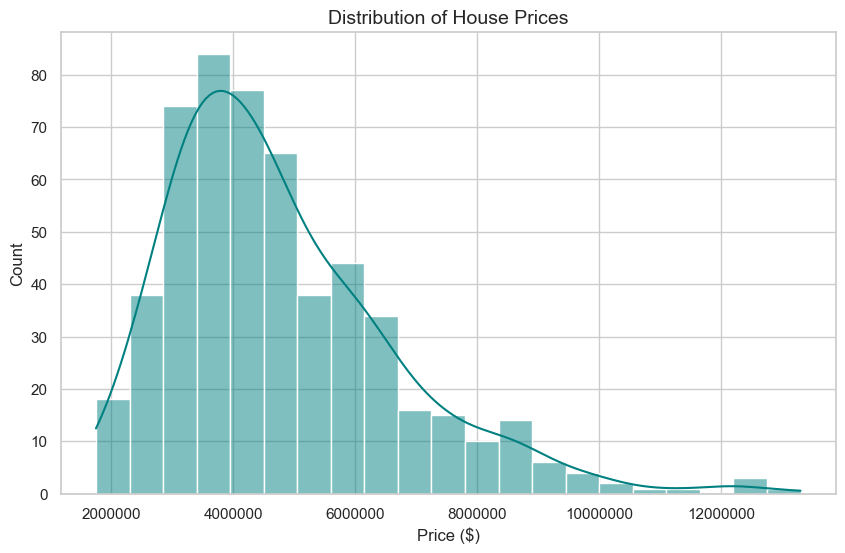

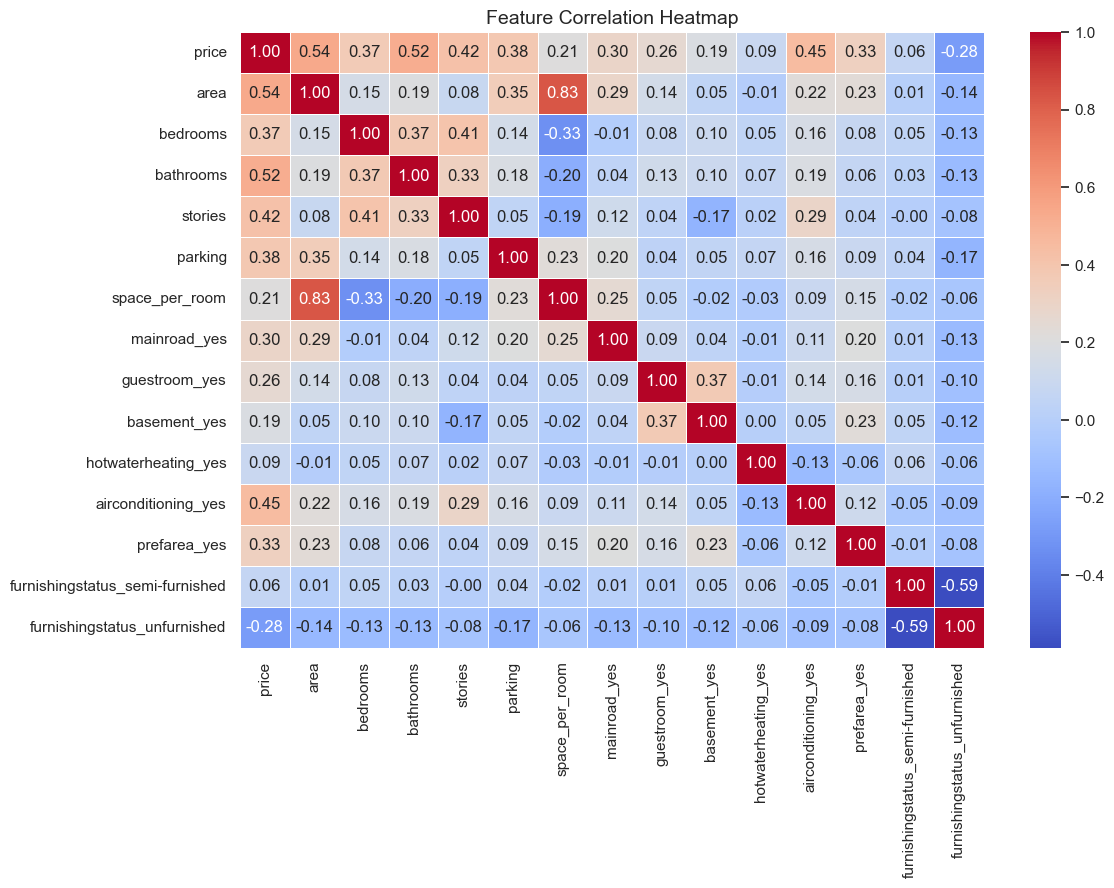

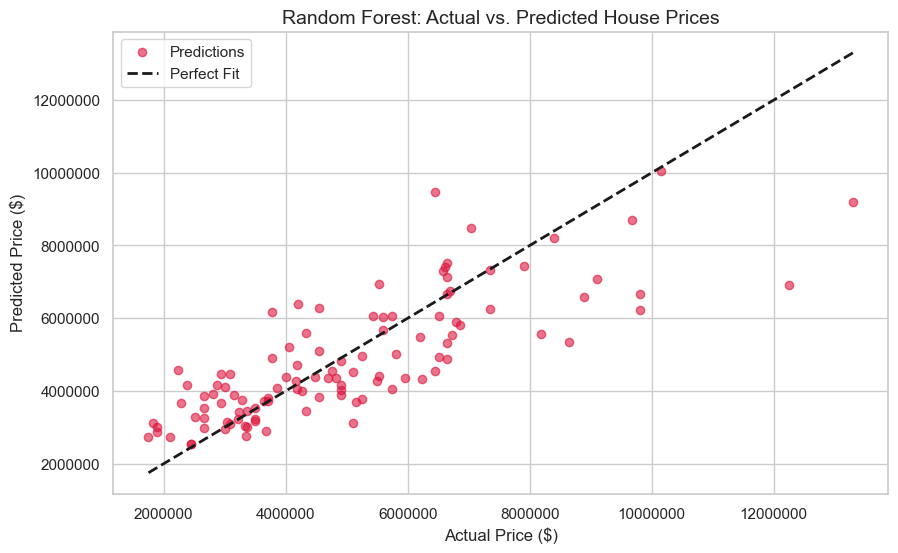

In [12]:
      ####---TASK 4---####
# Create charts directory if it doesn't exist
os.makedirs('charts', exist_ok=True)

# --- Chart 1: Distribution of House Prices ---
plt.figure()
sns.histplot(df['price'], kde=True, color='teal')
plt.title('Distribution of House Prices', fontsize=14)
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.ticklabel_format(style='plain', axis='x')
plt.savefig('charts/chart1_price_distribution.png', bbox_inches='tight')
plt.show()

# --- Chart 2: Correlation Heatmap ---
plt.figure(figsize=(12, 8))
# Only correlate numeric features from the encoded dataframe
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.savefig('charts/chart2_correlation_heatmap.png', bbox_inches='tight')
plt.show()

# --- Chart 3: Actual vs. Predicted Prices (Creative Choice) ---
plt.figure()
plt.scatter(y_test, rf_preds, alpha=0.6, color='crimson', label='Predictions')
# Diagonal perfect-fit line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Perfect Fit')
plt.title('Random Forest: Actual vs. Predicted House Prices', fontsize=14)
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.ticklabel_format(style='plain', axis='both')
plt.legend()
plt.savefig('charts/chart3_actual_vs_predicted.png', bbox_inches='tight')
plt.show()

In [11]:
# Get feature importances from Random Forest
importances = rf_model.feature_importances_
feature_names = X.columns

# Sort them in descending order
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print("--- Feature Importance According to Random Forest ---")
print(feature_importance_df.to_string(index=False))

--- Feature Importance According to Random Forest ---
                        Feature  Importance
                           area    0.449022
                      bathrooms    0.125901
                 space_per_room    0.099486
            airconditioning_yes    0.058421
                        parking    0.049026
                        stories    0.048090
   furnishingstatus_unfurnished    0.033787
                       bedrooms    0.031697
                   basement_yes    0.029037
                   prefarea_yes    0.026709
            hotwaterheating_yes    0.017229
                  guestroom_yes    0.011743
furnishingstatus_semi-furnished    0.010486
                   mainroad_yes    0.009367
